## Packages and Codes

In [22]:
# !pip install polars
# !pip install "numpy==1.26.4" "pyarrow>=14.0" "pandas==2.2.2"

In [1]:
from IPython.display import display, HTML
from google.cloud import bigquery
import pandas as pd
import pyarrow as pa
import polars as pl
import nest_asyncio
import os
import subprocess
import numpy as np
import scipy as sps
#from scipy.stats import linregress
#import scipy.stats as stats
import matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, date
#import pytz
import matplotlib.ticker as mticker
import json
import subprocess
import re

In [2]:
def wb(*args):
    """Run a wb command and return parsed JSON."""
    cmd = ["wb", *args, "--format=json"]
    result = subprocess.check_output(cmd, text=True)
    return json.loads(result)


# Get workspace info
workspace = wb("workspace", "describe")
GOOGLE_CLOUD_PROJECT = workspace["googleProjectId"]

# Get resources
resources = wb("resource", "list")

# WORKSPACE_BUCKET
bucket_resources = [
    r for r in resources
    if r.get("resourceType") == "GCS_BUCKET"
    and "practical_considerations_bucket" in r.get("id", "")
    and "temporary" not in r.get("id", "")
]

if not bucket_resources:
    raise ValueError("No matching bucket found")

WORKSPACE_BUCKET = f"gs://{bucket_resources[0]['bucketName']}"

# WORKSPACE_CDR
bq_resources = [
    r for r in resources
    if r.get("resourceType") in {"BQ_DATASET", "BIGQUERY_DATASET"}
]

cdr_resources = [
    r for r in bq_resources
    if re.match(r"^C\d{4}Q\d+R\d+$", r.get("datasetId", ""))
]

if not cdr_resources:
    raise ValueError("No matching CDR dataset found")

WORKSPACE_CDR = (
    f"{cdr_resources[0]['projectId']}."
    f"{cdr_resources[0]['datasetId']}"
)

nlp_ds = (f"{cdr_resources[0]['projectId']}.C_V9_R6_offcycle_nlp")

In [3]:
#get variables from env vars in notebook 00
version = WORKSPACE_CDR
bucket = WORKSPACE_BUCKET
cohort = "allofus"

In [4]:
# This line allows for the plots to be displayed inline in the Jupyter notebook
# %matplotlib inline

# # sns.set(style="whitegrid",font_scale=0.9)

palette = ['#0173b2', '#de8f05', '#8de5a1', '#d55e00', '#029e73', '#cc78bc', '#ece133', 
           '#56b4e9', '#ca9161', '#fbafe4', '#949494']

sns.set_palette(sns.color_palette(palette))
sns.color_palette(palette)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451)]

In [5]:
# show all columns in pandas
pd.set_option("display.max_columns", None)

# show full column width
pd.set_option('display.max_colwidth', 100)

# Polars string length to 100
pl.Config.set_fmt_str_lengths(100)

pl.Config.set_tbl_rows(50)

polars.config.Config

## Helper Functions

In [6]:
def polars_gbq(query):
    """
    Take a SQL query and return result as polars dataframe
    :param query: BigQuery SQL query
    :return: polars dataframe
    """
    client = bigquery.Client()
    query_job = client.query(query)
    rows = query_job.result()
    df = pl.from_arrow(rows.to_arrow())

    return df

def percentile_dates_from_monthly_counts(df, column, qs=(0.25, 0.50, 0.75)):
    """
    Find dates where cumulative counts reach 25%, 50%, and 75% of the total count.
    """
    values = df[column].fillna(0).to_numpy(dtype=float)
    cumulative = np.cumsum(values)
    total = cumulative[-1]

    if total == 0:
        return {}

    percentile_dates = {}
    for q in qs:
        idx = np.searchsorted(cumulative, q * total)
        idx = min(idx, len(df) - 1)
        percentile_dates[q] = pd.to_datetime(df.index[idx])

    return percentile_dates

def round_up_to_nearest(value, base=100000):
    """
    Round value up to the nearest `base`.
    """
    if value <= 0:
        return base
    return int(np.ceil(value / base) * base)

## EHR Data Density

Types of PPI: Observation, Meas Value, Measurement, Condition, Drug  
Survey concepts in observation: concept_id = "PPI" AND domain_id = "Condition"

### Create DFs by month

In [7]:
# surveys per month for whole cohort
survey_months_q = f"""
WITH surveys AS (
    SELECT person_id AS person, o.observation_id AS survey_id, o.observation_date AS date,
    FROM {version}.observation AS o
    JOIN {version}.concept AS c ON o.observation_source_value = c.concept_code
    WHERE c.vocabulary_id = 'PPI' AND c.domain_id = 'Observation'
),
all_dates AS (
  SELECT date 
  FROM (
    SELECT date FROM surveys
  )
  GROUP BY date
),
monthly_counts AS (
  SELECT 
    DATE_TRUNC(d.date, MONTH) as month,
    COUNT(DISTINCT s.survey_id) AS survey_count,
    COUNT(DISTINCT s.person) AS survey_person_count,
  FROM all_dates d
  LEFT JOIN surveys s ON DATE_TRUNC(d.date, MONTH) = DATE_TRUNC(s.date, MONTH)  -- Changed join condition
  GROUP BY month
)
SELECT * FROM monthly_counts
ORDER BY month
"""

survey_months_df = polars_gbq(survey_months_q)

In [8]:
# procedures per month for whole cohort
procedures_months_q = f"""
WITH procedures AS (
    SELECT person_id AS person, p.procedure_occurrence_id AS procedure_id, p.procedure_date AS date
    FROM {version}.procedure_occurrence AS p
    JOIN {version}.concept AS c ON p.procedure_concept_id = c.concept_id
    WHERE c.domain_id = 'Procedure'
),
all_dates AS (
  SELECT date 
  FROM (
    SELECT date FROM procedures
  )
  GROUP BY date
),
monthly_counts AS (
  SELECT 
    DATE_TRUNC(d.date, MONTH) as month,
    COUNT(DISTINCT p.procedure_id) AS procedure_count,
    COUNT(DISTINCT p.person) AS procedure_person_count,
  FROM all_dates d
  LEFT JOIN procedures p ON DATE_TRUNC(d.date, MONTH) = DATE_TRUNC(p.date, MONTH)
  GROUP BY month
)
SELECT * FROM monthly_counts
ORDER BY month
"""

procedures_months_df = polars_gbq(procedures_months_q)

In [9]:
# conditions per month for whole cohort
conditions_months_q = f"""
WITH conditions AS (
    SELECT person_id AS person, o.observation_id AS condition_id, o.observation_date AS date,
    FROM {version}.observation AS o
    JOIN {version}.concept AS c ON o.observation_source_value = c.concept_code
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')

    UNION ALL

    SELECT person_id AS person, o.observation_id AS condition_id, o.observation_date AS date,
    FROM {version}.observation AS o
    JOIN {version}.concept AS c ON o.observation_source_concept_id = c.concept_id
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')

    UNION ALL

    SELECT person_id AS person, co.condition_occurrence_id AS condition_id, co.condition_start_date AS date,
    FROM {version}.condition_occurrence AS co
    JOIN {version}.concept AS c ON co.condition_source_value = c.concept_code
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')

    UNION ALL

    SELECT person_id AS person, co.condition_occurrence_id AS condition_id, co.condition_start_date AS date,
    FROM {version}.condition_occurrence AS co
    JOIN {version}.concept AS c ON co.condition_source_concept_id = c.concept_id
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
),
all_dates AS (
  SELECT date 
  FROM (
    SELECT date FROM conditions
  )
  GROUP BY date
),
monthly_counts AS (
  SELECT 
    DATE_TRUNC(d.date, MONTH) as month,
    COUNT(DISTINCT c.condition_id) AS condition_count,
    COUNT(DISTINCT c.person) AS condition_person_count,
  FROM all_dates d
  LEFT JOIN conditions c ON DATE_TRUNC(d.date, MONTH) = DATE_TRUNC(c.date, MONTH)
  GROUP BY month
)
SELECT * FROM monthly_counts
ORDER BY month
"""

conditions_months_df = polars_gbq(conditions_months_q)

In [10]:
# measurements per month for whole cohort
measurements_months_q = f"""
WITH measurements AS (
    SELECT
        m.person_id AS person,
        m.measurement_id,
        m.measurement_date AS date,
        CASE
            WHEN LOWER(TRIM(CAST(me.src_id AS STRING))) LIKE '%ehr%'
                THEN 'ehr'

            WHEN TRIM(CAST(me.src_id AS STRING)) IN (
                'Participant Portal: TPC',
                'Participant Portal: PTSC',
                'Staff Portal: HealthPro'
            )
                THEN 'ppi'

            ELSE 'unknown'
        END AS source_type

    FROM {version}.measurement AS m
    JOIN {version}.concept AS c
        ON m.measurement_concept_id = c.concept_id
    LEFT JOIN {version}.measurement_ext AS me
        ON m.measurement_id = me.measurement_id

    WHERE c.domain_id = 'Measurement'
),

monthly_counts AS (
    SELECT
        DATE_TRUNC(date, MONTH) AS month,

        COUNT(DISTINCT IF(source_type = 'ehr', measurement_id, NULL))
            AS ehr_measurement_count,

        COUNT(DISTINCT IF(source_type = 'ehr', person, NULL))
            AS ehr_measurement_person_count,

        COUNT(DISTINCT IF(source_type = 'ppi', measurement_id, NULL))
            AS ppi_measurement_count,

        COUNT(DISTINCT IF(source_type = 'ppi', person, NULL))
            AS ppi_measurement_person_count

    FROM measurements
    GROUP BY month
)

SELECT *
FROM monthly_counts
ORDER BY month
"""

measurements_months_df = polars_gbq(measurements_months_q)

In [11]:
# drugs per month for whole cohort
drugs_months_q = f"""
WITH drugs AS (
    SELECT person_id AS person, de.drug_exposure_id AS drug_id, de.drug_exposure_start_date AS date
    FROM {version}.drug_exposure AS de
    JOIN {version}.concept AS c ON de.drug_concept_id = c.concept_id
    WHERE c.domain_id = 'Drug'
),
all_dates AS (
  SELECT date 
  FROM (
    SELECT date FROM drugs
  )
  GROUP BY date
),
monthly_counts AS (
  SELECT 
    DATE_TRUNC(d.date, MONTH) as month,
    COUNT(DISTINCT dr.drug_id) AS drug_count,
    COUNT(DISTINCT dr.person) AS drug_person_count
  FROM all_dates d
  LEFT JOIN drugs dr ON DATE_TRUNC(d.date, MONTH) = DATE_TRUNC(dr.date, MONTH)
  GROUP BY month
)
SELECT * FROM monthly_counts
ORDER BY month
"""

drugs_months_df = polars_gbq(drugs_months_q)

In [22]:
# wearables per month for whole cohort
wearables_months_q = f"""
WITH wearables AS (
    SELECT 
        person_id AS person,
        CONCAT(CAST(person_id AS STRING), '-', FORMAT_DATE('%F', act.date)) AS wearable_id,
        act.date AS date
    FROM {version}.activity_summary AS act
    
    UNION ALL
    
    SELECT 
        person_id AS person,
        CONCAT(CAST(person_id AS STRING), '-', FORMAT_DATE('%F', sds.sleep_date)) AS wearable_id,
        sds.sleep_date AS date
    FROM {version}.sleep_daily_summary AS sds
    
    UNION ALL
    
    SELECT 
        person_id AS person,
        CONCAT(CAST(person_id AS STRING), '-', FORMAT_DATE('%F', hrs.date)) AS wearable_id,
        hrs.date AS date
    FROM {version}.heart_rate_summary AS hrs
),
all_dates AS (
  SELECT date 
  FROM (
    SELECT date FROM wearables
  )
  GROUP BY date
),
monthly_counts AS (
  SELECT 
    DATE_TRUNC(d.date, MONTH) as month,
    COUNT(DISTINCT w.wearable_id) AS wearable_count,
    COUNT(DISTINCT w.person) AS wearable_person_count
  FROM all_dates d
  LEFT JOIN wearables w ON DATE_TRUNC(d.date, MONTH) = DATE_TRUNC(w.date, MONTH)
  GROUP BY month
)
SELECT * FROM monthly_counts
ORDER BY month
"""
wearables_months_df = polars_gbq(wearables_months_q)

In [13]:
# notes per month for whole cohort
## for nlp table, use "note_nlp" instead of "note" table
notes_months_q = f"""
WITH notes AS (
    SELECT
        nlp.note_id        AS note_id,
        nlp.note_date      AS date
    FROM
        {nlp_ds}.note AS nlp
),
all_dates AS (
    SELECT date
    FROM notes
    GROUP BY date
),
monthly_counts AS (
    SELECT
        DATE_TRUNC(d.date, MONTH)           AS month,
        COUNT(DISTINCT n.note_id)           AS note_count
    FROM all_dates d
    LEFT JOIN notes n
        ON DATE_TRUNC(d.date, MONTH) = DATE_TRUNC(n.date, MONTH)
    GROUP BY month
)
SELECT * FROM monthly_counts
ORDER BY month
"""
notes_months_df = polars_gbq(notes_months_q)

In [14]:
# cognitive tasks per month for whole cohort
cognitive_months_q = f"""
WITH cognitive_tasks AS (
    SELECT 
        person_id AS person,
        CONCAT(CAST(person_id AS STRING), '-', FORMAT_DATE('%F', DATE(dd.metadata.test_start_date_time))) AS task_id,
        DATE(dd.metadata.test_start_date_time) AS date
    FROM {version}.delaydiscounting AS dd
    
    UNION ALL
    
    SELECT 
        person_id AS person,
        CONCAT(CAST(person_id AS STRING), '-', FORMAT_DATE('%F', DATE(er.metadata.test_start_date_time))) AS task_id,
        DATE(er.metadata.test_start_date_time) AS date
    FROM {version}.emorecog AS er
    
    UNION ALL
    
    SELECT 
        person_id AS person,
        CONCAT(CAST(person_id AS STRING), '-', FORMAT_DATE('%F', DATE(gc.metadata.test_start_date_time))) AS task_id,
        DATE(gc.metadata.test_start_date_time) AS date
    FROM {version}.gradcpt AS gc
    
    UNION ALL
    
    SELECT 
        person_id AS person,
        CONCAT(CAST(person_id AS STRING), '-', FORMAT_DATE('%F', DATE(fl.metadata.test_start_date_time))) AS task_id,
        DATE(fl.metadata.test_start_date_time) AS date
    FROM {version}.flanker AS fl
),
all_dates AS (
  SELECT date 
  FROM (
    SELECT date FROM cognitive_tasks
  )
  GROUP BY date
),
monthly_counts AS (
  SELECT 
    DATE_TRUNC(d.date, MONTH) as month,
    COUNT(DISTINCT c.task_id) AS task_count,
    COUNT(DISTINCT c.person) AS task_person_count
  FROM all_dates d
  LEFT JOIN cognitive_tasks c ON DATE_TRUNC(d.date, MONTH) = DATE_TRUNC(c.date, MONTH)
  GROUP BY month
)
SELECT * FROM monthly_counts
ORDER BY month
"""
cognitive_months_df = polars_gbq(cognitive_months_q)

In [23]:
merged_months_df = (
    procedures_months_df
    .join(survey_months_df, on="month", how="full", coalesce=True)
    .join(conditions_months_df, on="month", how="full", coalesce=True)
    .join(measurements_months_df, on="month", how="full", coalesce=True)
    .join(drugs_months_df, on="month", how="full", coalesce=True)
    .join(wearables_months_df, on="month", how="full", coalesce=True)
    .join(notes_months_df, on="month", how="full", coalesce=True)
    .join(cognitive_months_df, on="month", how="full", coalesce=True)
).sort("month")

## Plot

In [16]:
# ##read in file if previously saved:
# merged_months_df = pl.read_csv('/home/jupyter/workspace/practical_considerations_bucket/data/aou_v9_cohort.csv')

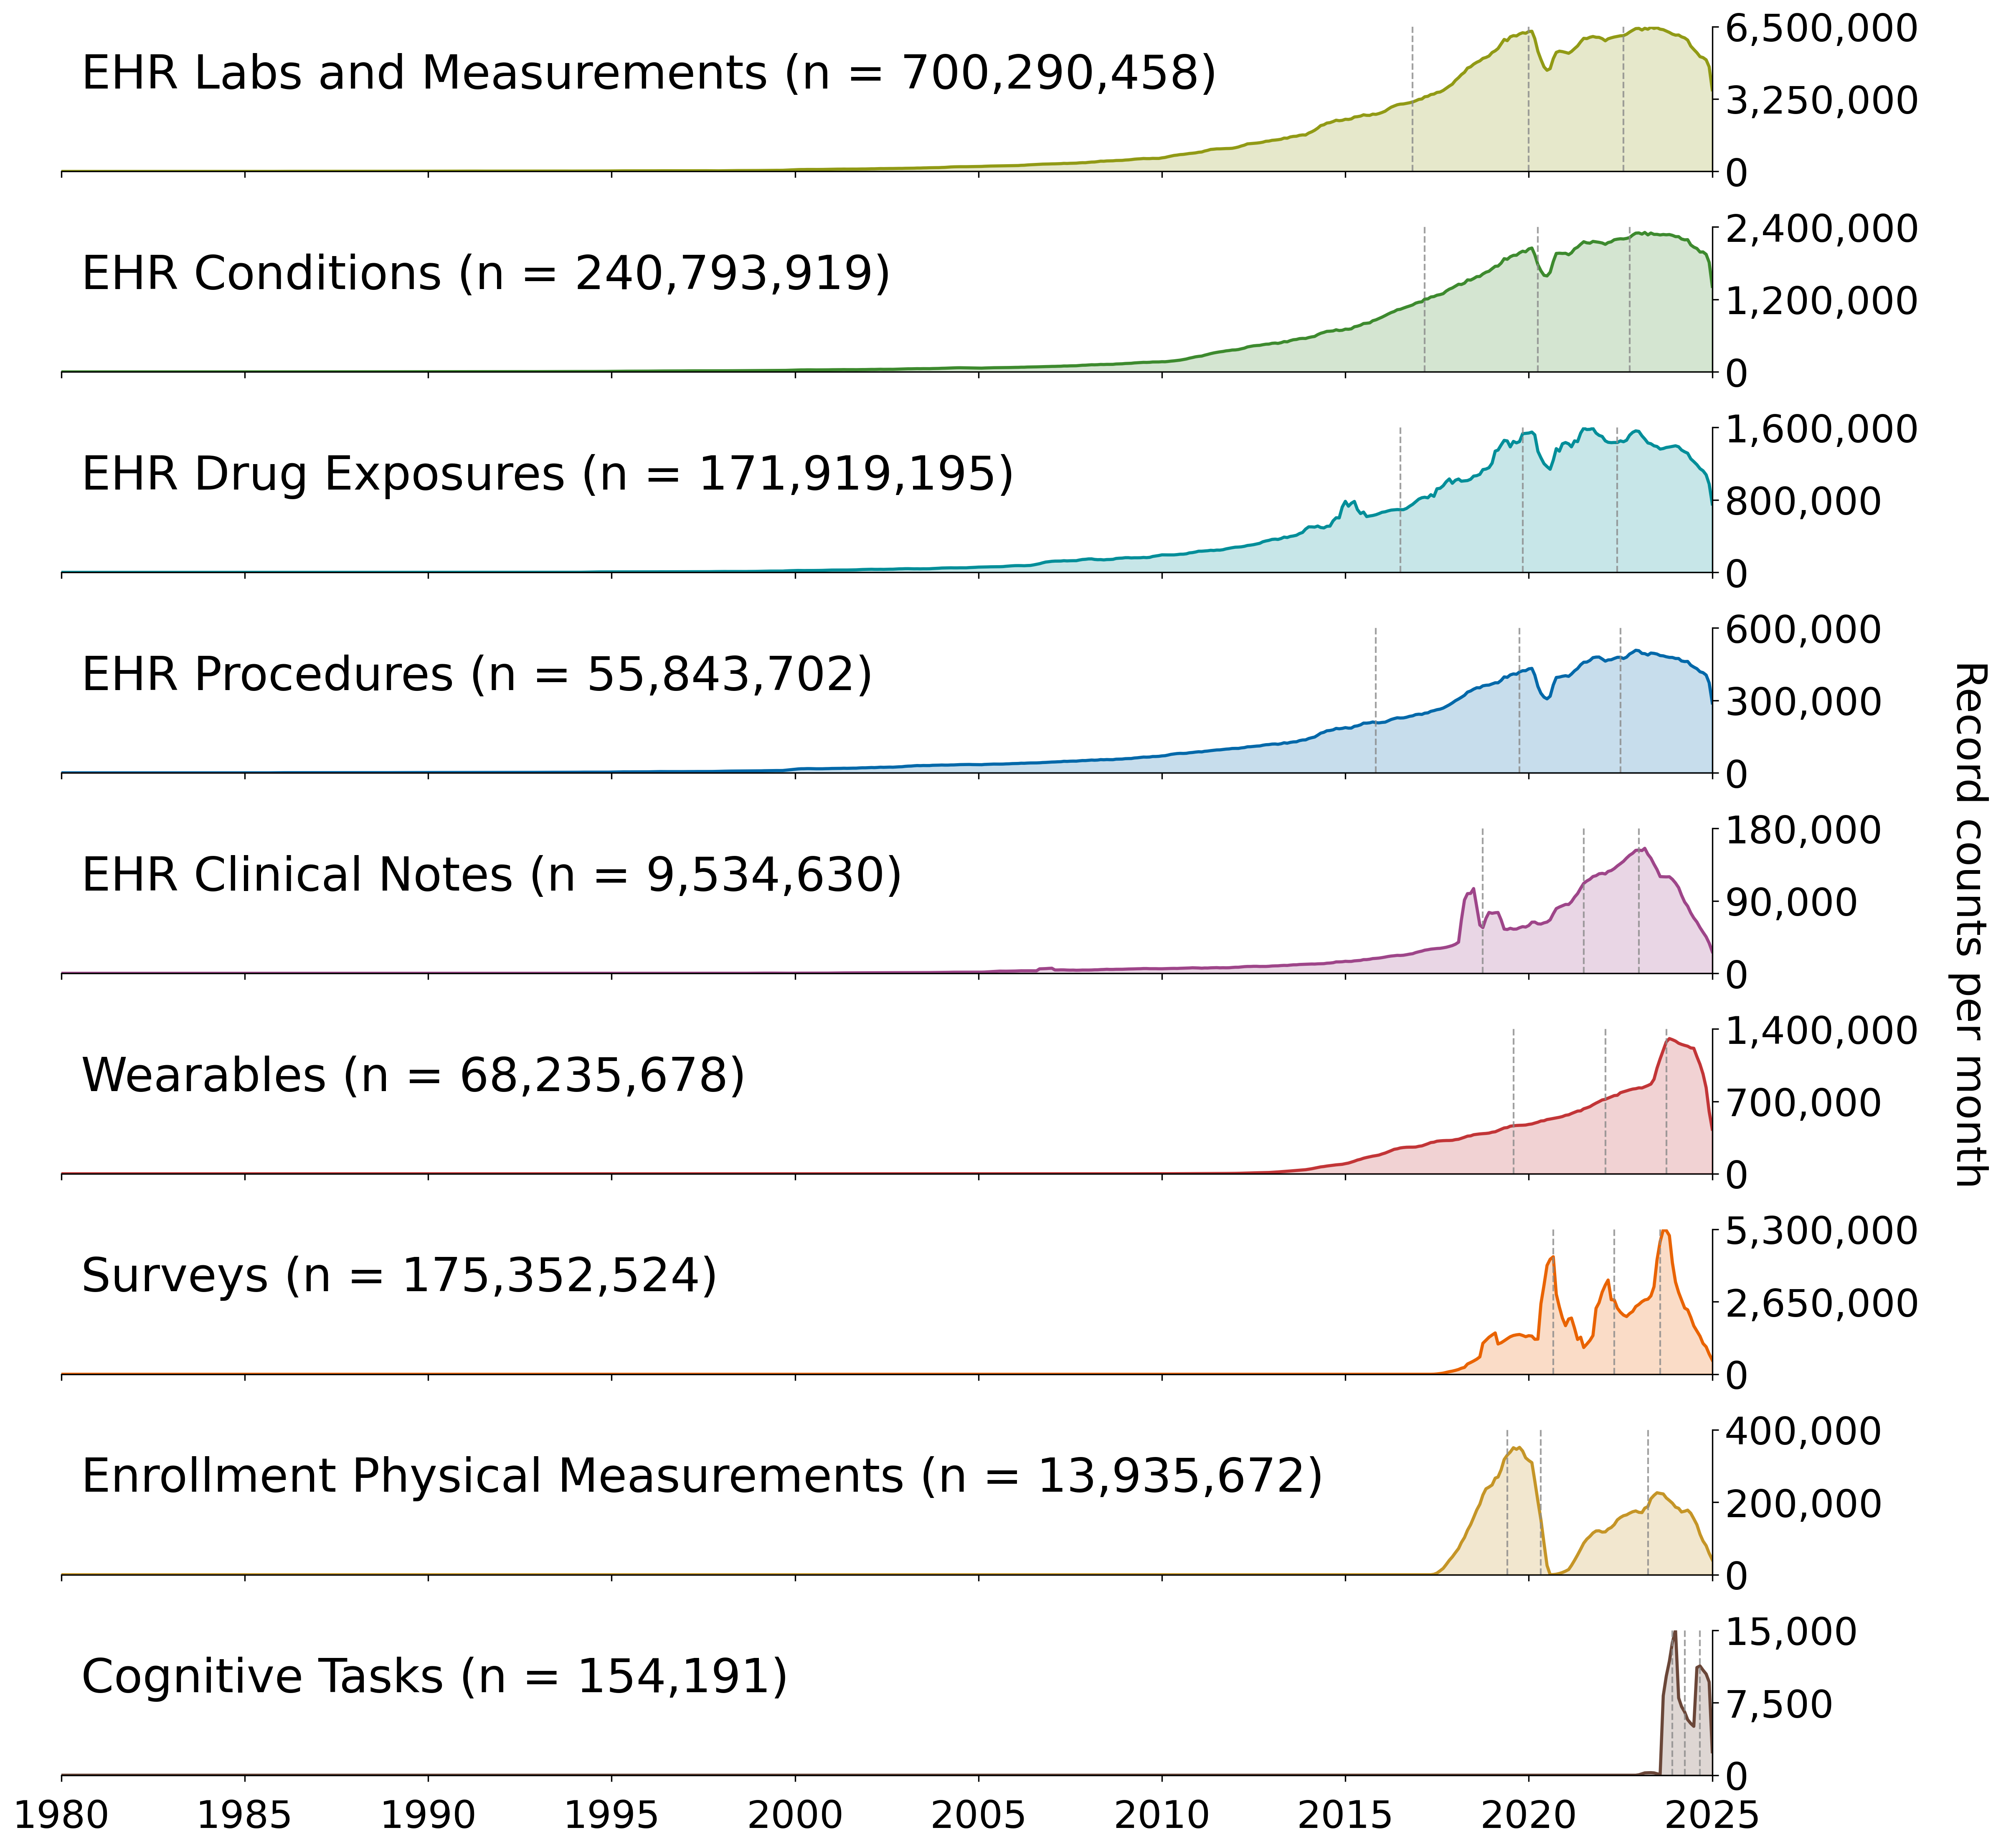

In [35]:
# Settings
color_dict = {
    'ehr_measurement_count': '#919A15',
    'condition_count': '#3D8A2E',
    'drug_count': '#028E99',
    'procedure_count': '#0168A9',
    'note_count': '#9E4589',
    'wearable_count': '#C23537',
    'survey_count': '#E96301',
    'ppi_measurement_count': '#C59527',
    'task_count': '#6A4638',
}
pretty_names = {
    'survey_count': 'Surveys',
    'task_count': 'Cognitive Tasks',
    'procedure_count': 'EHR Procedures',
    'condition_count': 'EHR Conditions',
    'ppi_measurement_count': 'Enrollment Physical Measurements',
    'ehr_measurement_count': 'EHR Labs and Measurements',
    'drug_count': 'EHR Drug Exposures',
    'note_count': 'EHR Clinical Notes',
    'wearable_count': 'Wearables'
}
columns_to_plot = [
    'ehr_measurement_count',
    'condition_count',
    'drug_count',
    'procedure_count',
    'note_count',
    'wearable_count',
    'survey_count',
    'ppi_measurement_count',
    'task_count'
]

# Font Sizes
TITLE_SIZE = 27
YTICK_SIZE = 22
XTICK_SIZE = 22
YLABEL_SIZE = 24

# Shorter panels
FIG_WIDTH = 16
FIG_HEIGHT_PER_PANEL = 1.65

# Helper: round up to the nearest given increment
def round_up_to_nearest(value, nearest=100000):
    if value <= 0:
        return nearest
    return int(np.ceil(value / nearest) * nearest)

# Manual y-axis max overrides for panels where auto-rounding leaves too much headroom
ymax_overrides = {
    'task_count': 15000,
    'note_count': 180000,
}

# Prepare data
rolling_cols = [
    col for col in columns_to_plot
    if col in merged_months_df.columns
]
df_wide = (
    merged_months_df
    .sort("month")
    .fill_null(0)
    .with_columns([
        pl.col(col).rolling_mean(window_size=5).alias(col)
        for col in rolling_cols
    ])
)
df_plot = df_wide.to_pandas().set_index("month")

# Keep only columns that actually exist
columns_to_plot = [c for c in columns_to_plot if c in df_plot.columns]

# Plot
fig, axes = plt.subplots(
    len(columns_to_plot),
    1,
    figsize=(FIG_WIDTH, FIG_HEIGHT_PER_PANEL * len(columns_to_plot)),
    sharex=True,
    dpi=300
)
if len(columns_to_plot) == 1:
    axes = [axes]

for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    sns.despine(ax=ax, top=True, left=True, right=False)

    x = df_plot.index
    y = df_plot[column].fillna(0)

    # Main line + fill
    ax.plot(
        x,
        y,
        color=color_dict[column],
        linewidth=1.8
    )
    ax.fill_between(
        x,
        y,
        color=color_dict[column],
        alpha=0.22
    )

    # Percentile lines (unlabeled)
    percentile_dates = percentile_dates_from_monthly_counts(
        df_plot,
        column,
        qs=(0.25, 0.50, 0.75)
    )
    for d in percentile_dates.values():
        ax.axvline(
            d,
            linestyle="--",
            linewidth=1,
            color="#8a8a8a",
            alpha=0.8
        )

    # Top-left label
    total_n = int(np.nansum(y))
    ax.text(
        0.012,
        0.82,
        f"{pretty_names[column]} (n = {total_n:,})",
        transform=ax.transAxes,
        fontsize=TITLE_SIZE,
        ha="left",
        va="top"
    )

    # Right-side y-axis with only 3 ticks, rounded max (nearest 100k, with manual overrides)
    ymax_raw = np.nanmax(y)
    ymax = ymax_overrides.get(column, round_up_to_nearest(ymax_raw, 100000))
    ax.set_ylim(0, ymax)
    ax.set_yticks([0, ymax / 2, ymax])
    ax.set_yticklabels([
        "0",
        f"{ymax/2:,.0f}",
        f"{ymax:,.0f}"
    ])
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.tick_params(
        axis='y',
        right=True,
        left=False,
        labelright=True,
        labelleft=False,
        labelsize=YTICK_SIZE
    )
    ax.tick_params(
        axis='x',
        labelsize=XTICK_SIZE
    )
    ax.spines["left"].set_visible(False)
    ax.grid(False)
    ax.set_ylabel("")

# Shared axis formatting
axes[-1].set_xlim(
    pd.to_datetime("1980-01-01"),
    pd.to_datetime("2025-01-01")
)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(base=5))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].tick_params(axis='x', pad=10)

fig.text(
    0.985,
    0.5,
    "Record counts per month",
    rotation=-90,
    va="center",
    ha="center",
    fontsize=YLABEL_SIZE
)

plt.tight_layout(rect=(0, 0, 0.97, 1))
plt.show()

In [36]:
##save figure and table to bucket
for ext in ["pdf"]:
    fig.savefig(f"/home/jupyter/workspace/practical_considerations_bucket/data/fig_1_aou_data_v9.{ext}", dpi=300, bbox_inches="tight")
    #change "jupyter" to "dataproc" if in a dataproc workspace for other analyses

In [37]:
#save to avoid querying every time
merged_months_df.write_csv('/home/jupyter/workspace/practical_considerations_bucket/data/aou_v9_cohort.csv')

In [38]:
rows = []

for col in columns_to_plot:
    if col not in df_plot.columns:
        continue

    y = df_plot[col].fillna(0)

    if y.sum() == 0:
        continue

    percentile_dates = percentile_dates_from_monthly_counts(
        df_plot,
        col,
        qs=(0.25, 0.50, 0.75)
    )

    date_min = df_plot.index[y > 0].min().strftime("%Y-%m")
    date_max = df_plot.index[y > 0].max().strftime("%Y-%m")

    rows.append({
        "Data Type":  pretty_names[col],
        "Start":      date_min,
        "End":        date_max,
        "Q1 (25%)":   percentile_dates[0.25].strftime("%Y-%m"),
        "Median":     percentile_dates[0.50].strftime("%Y-%m"),
        "Q3 (75%)":   percentile_dates[0.75].strftime("%Y-%m"),
    })

summary_df = pd.DataFrame(rows)

In [39]:
unique_persons_surveys_q = f"""
SELECT COUNT(DISTINCT o.person_id) AS unique_person_count
FROM {version}.observation AS o
JOIN {version}.concept AS c ON o.observation_source_value = c.concept_code
WHERE c.vocabulary_id = 'PPI' AND c.domain_id = 'Observation'
"""

unique_persons_procedures_q = f"""
SELECT COUNT(DISTINCT p.person_id) AS unique_person_count
FROM {version}.procedure_occurrence AS p
JOIN {version}.concept AS c ON p.procedure_concept_id = c.concept_id
WHERE c.domain_id = 'Procedure'
"""

unique_persons_conditions_q = f"""
SELECT COUNT(DISTINCT person_id) AS unique_person_count
FROM (
    SELECT person_id FROM {version}.observation AS o
    JOIN {version}.concept AS c ON o.observation_source_value = c.concept_code
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
    UNION ALL
    SELECT person_id FROM {version}.observation AS o
    JOIN {version}.concept AS c ON o.observation_source_concept_id = c.concept_id
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
    UNION ALL
    SELECT person_id FROM {version}.condition_occurrence AS co
    JOIN {version}.concept AS c ON co.condition_source_value = c.concept_code
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
    UNION ALL
    SELECT person_id FROM {version}.condition_occurrence AS co
    JOIN {version}.concept AS c ON co.condition_source_concept_id = c.concept_id
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
)
"""

unique_persons_measurements_ehr_q = f"""
SELECT
    COUNT(DISTINCT IF(LOWER(TRIM(CAST(me.src_id AS STRING))) LIKE '%ehr%', m.person_id, NULL)) AS ehr_unique_person_count,
    COUNT(DISTINCT IF(TRIM(CAST(me.src_id AS STRING)) IN (
        'Participant Portal: TPC',
        'Participant Portal: PTSC',
        'Staff Portal: HealthPro'
    ), m.person_id, NULL)) AS ppi_unique_person_count
FROM {version}.measurement AS m
JOIN {version}.concept AS c ON m.measurement_concept_id = c.concept_id
LEFT JOIN {version}.measurement_ext AS me ON m.measurement_id = me.measurement_id
WHERE c.domain_id = 'Measurement'
"""

unique_persons_drugs_q = f"""
SELECT COUNT(DISTINCT de.person_id) AS unique_person_count
FROM {version}.drug_exposure AS de
JOIN {version}.concept AS c ON de.drug_concept_id = c.concept_id
WHERE c.domain_id = 'Drug'
"""

unique_persons_wearables_q = f"""
SELECT COUNT(DISTINCT person_id) AS unique_person_count
FROM (
    SELECT person_id FROM {version}.activity_summary
    UNION ALL
    SELECT person_id FROM {version}.sleep_daily_summary
    UNION ALL
    SELECT person_id FROM {version}.heart_rate_summary
)
"""

unique_persons_cognitive_tasks_q = f"""
SELECT COUNT(DISTINCT person_id) AS unique_person_count
FROM (
    SELECT person_id FROM {version}.delaydiscounting
    UNION ALL
    SELECT person_id FROM {version}.emorecog
    UNION ALL
    SELECT person_id FROM {version}.gradcpt
    UNION ALL
    SELECT person_id FROM {version}.flanker
)
"""

unique_persons_notes_q = f"""
SELECT COUNT(DISTINCT note.person_id) AS unique_person_count
FROM {nlp_ds}.note
"""

unique_persons_ehr_q = f"""
SELECT COUNT(DISTINCT person_id) AS unique_person_count
FROM (
    -- procedures
    SELECT p.person_id FROM {version}.procedure_occurrence AS p
    JOIN {version}.concept AS c ON p.procedure_concept_id = c.concept_id
    WHERE c.domain_id = 'Procedure'

    UNION ALL

    -- conditions
    SELECT person_id FROM {version}.observation AS o
    JOIN {version}.concept AS c ON o.observation_source_value = c.concept_code
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
    UNION ALL
    SELECT person_id FROM {version}.observation AS o
    JOIN {version}.concept AS c ON o.observation_source_concept_id = c.concept_id
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
    UNION ALL
    SELECT person_id FROM {version}.condition_occurrence AS co
    JOIN {version}.concept AS c ON co.condition_source_value = c.concept_code
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')
    UNION ALL
    SELECT person_id FROM {version}.condition_occurrence AS co
    JOIN {version}.concept AS c ON co.condition_source_concept_id = c.concept_id
    WHERE c.vocabulary_id IN ('ICD9CM', 'ICD10CM', 'SNOMED')

    UNION ALL

    -- ehr measurements
    SELECT m.person_id FROM {version}.measurement AS m
    JOIN {version}.concept AS c ON m.measurement_concept_id = c.concept_id
    LEFT JOIN {version}.measurement_ext AS me ON m.measurement_id = me.measurement_id
    WHERE c.domain_id = 'Measurement'
    AND LOWER(TRIM(CAST(me.src_id AS STRING))) LIKE '%ehr%'

    UNION ALL

    -- drugs
    SELECT de.person_id FROM {version}.drug_exposure AS de
    JOIN {version}.concept AS c ON de.drug_concept_id = c.concept_id
    WHERE c.domain_id = 'Drug'

    UNION ALL

    -- notes
    SELECT person_id FROM {nlp_ds}.note
)
"""

# Run all queries
results = {
    "surveys":            polars_gbq(unique_persons_surveys_q)["unique_person_count"][0],
    "procedures":         polars_gbq(unique_persons_procedures_q)["unique_person_count"][0],
    "conditions":         polars_gbq(unique_persons_conditions_q)["unique_person_count"][0],
    "ehr_measurements":   polars_gbq(unique_persons_measurements_ehr_q)["ehr_unique_person_count"][0],
    "ppi_measurements":   polars_gbq(unique_persons_measurements_ehr_q)["ppi_unique_person_count"][0],
    "drugs":              polars_gbq(unique_persons_drugs_q)["unique_person_count"][0],
    "wearables":          polars_gbq(unique_persons_wearables_q)["unique_person_count"][0],
    "cognitive_tasks":    polars_gbq(unique_persons_cognitive_tasks_q)["unique_person_count"][0],
    "notes":              polars_gbq(unique_persons_notes_q)["unique_person_count"][0],
    "ehr_any":            polars_gbq(unique_persons_ehr_q)["unique_person_count"][0],
}

unique_persons_df = pl.DataFrame({
    "data_type":          list(results.keys()),
    "unique_person_count": list(results.values()),
})

print(unique_persons_df)

shape: (10, 2)
┌──────────────────┬─────────────────────┐
│ data_type        ┆ unique_person_count │
│ ---              ┆ ---                 │
│ str              ┆ i64                 │
╞══════════════════╪═════════════════════╡
│ surveys          ┆ 747029              │
│ procedures       ┆ 414570              │
│ conditions       ┆ 434881              │
│ ehr_measurements ┆ 436867              │
│ ppi_measurements ┆ 600828              │
│ drugs            ┆ 418203              │
│ wearables        ┆ 68779               │
│ cognitive_tasks  ┆ 97712               │
│ notes            ┆ 99839               │
│ ehr_any          ┆ 463901              │
└──────────────────┴─────────────────────┘
